# 2026-10-03 · The previous-token profile in the effective model

The previous-token diagonal $m_\nu=\bm M_{\nu,\nu-1}$ is not a single number. It is a profile that weakens along the sequence. The theory is in two scratch notes:
- `paper/scratch/2026-10-03-1309_subdiagonal-profile-signal-ansatz.tex`: why the profile has this shape;
- `paper/scratch/2026-10-03-1539_profile-ansatz.tex`: the logit classes with a profile.

In code the profile is one optional key, `order_params["M_profile"]`. It is a tensor of length $L-1$, in the convention of `M.diagonal(-1)` and with the sign of $\bm M$. When it is present it replaces the scalar `M_on`, which stays the logged mean. Everything else (the logits, the sampler, the effective loss, the flow) works unchanged.

This notebook uses `ansatz_test/run_002` ($V=128$, $L=512$).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from tracklab import ExperimentReader

from icl import (RunData, QueryTable, logit_table, logit_blocks, measure_variables, sample_variables,
                 ansatz_logits, EffectiveLoss, integrate, support_sizes)

# Save figure as svg
# path = Path('../../presentation/public/fig/')
path = Path('./')
# Make sure the directory exists
path.mkdir(parents=True, exist_ok=True)

# Plot Configs

In [2]:
"""
Script to set up the configurations for the plots.
"""
# Define font sizes
FONTSIZES = {
    'xxs': 4,
    'xs': 6,
    's': 8,
    'm': 10,
    'l': 12,
    'xl': 14,
    'xxl': 16
}

double_w = 7.2  # Width for double column
single_w = 3.5  # Width for single column

def set_font_sizes(conf='normal', factor=1, sizes=None):
    """
    Set font sizes for plots.
    """
    keys = ['font.size', 'axes.labelsize', 'axes.titlesize',
            'xtick.labelsize', 'ytick.labelsize',
            'legend.fontsize', 'figure.titlesize']
    
    if conf == 'normal':
        sizes = ['m', 'm', 'm', 's', 's', 's', 'l']
    elif conf == 'equal':
        sizes = ['m', 'm', 'm', 'm', 'm', 'm', 'm']
    elif conf == 'tight':
        sizes = ['s', 'm', 'm', 'xs', 'xs', 'xs', 'm']
    elif conf == 'custom':
        if sizes is None:
            raise ValueError("Must specify list of sizes (e.g., ['m', 'm', 'm', 's', 's', 's', 'l'])")
    
    for size, key in zip(sizes, keys):
        plt.rcParams[key] = FONTSIZES[size] * factor


def apply_general_styles():
    """
    Apply general plot styles.
    """
    plt.rcParams.update({
        'mathtext.fontset': 'cm',
        'font.family': 'STIXGeneral',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'figure.dpi': 150,
        'text.usetex': False,
        'text.latex.preamble': r'\usepackage{amsmath,amssymb}'
    })


def create_fig(nrows=1,ncols=1,size='single',w=1.0,h=0.5,layout='constrained',sharex=True,sharey=None,w_ratios=None,h_ratios=None):
    width = single_w if size=='single' else double_w
    figsize = (w*width,h*width)
    fig , axes = plt.subplots(nrows=nrows,ncols=ncols,figsize=figsize,layout=layout,sharex=sharex,sharey=sharey,gridspec_kw={'width_ratios': w_ratios, 'height_ratios': h_ratios})
    return fig , axes

apply_general_styles()
set_font_sizes(conf='tight')

# Code

## 1. The measured profile

`run.order_params(step, profile=True)` returns the scalar order parameters plus `"M_profile"`, the measured sub-diagonal.

Two quantities enter the logits:
- the profile itself, read at the keys of each occurrence;
- its running sum, `cumsum`. Divided by the number of keys, the running sum gives $\bar m_\mu$, the mean the logit classes depend on.

{'M_on': -13.95, 'M_off': 0.036, 'Q_on': -59.235, 'Q_T': -0.767, 'G_on': 25.233, 'G_T': -2.838}
M_profile: (511,) | its mean = M_on: -13.95


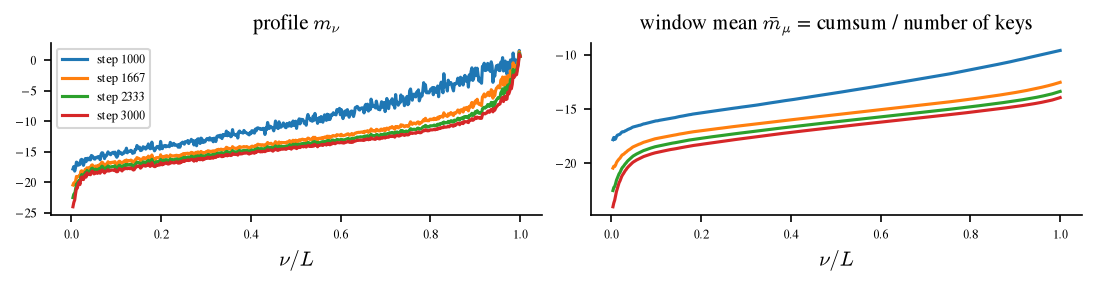

In [3]:
run = RunData("ansatz_test", "run_002", base_dir="../data")
config = run.config
L, V, K, beta = config.model_args.seq_len, config.model_args.vocab_size, config.data_args.K, config.model_args.beta
device = "cuda" if torch.cuda.is_available() else "cpu"
order_params = run.order_params("last", profile=True)
print({name: round(value, 3) for name, value in order_params.items() if name != "M_profile"})
print("M_profile:", tuple(order_params["M_profile"].shape), "| its mean = M_on:", round(order_params["M_profile"].mean().item(), 3))

x = np.arange(2, L + 1) / L                                  # nu / L for the keys nu = 2..L
fig, axes = create_fig(ncols=2, size='double', h=0.25, sharex=True)
for step in run.steps("matrices")[3::2]:
    profile = run.order_params(step, profile=True)["M_profile"].numpy()
    axes[0].plot(x, profile, label=f"step {step}")
    keys = np.arange(1, L)
    axes[1].plot(x, np.cumsum(profile) / keys, label=f"step {step}")
axes[0].set_title(r"profile $m_\nu$"); axes[1].set_title(r"window mean $\bar m_\mu$ = cumsum / number of keys")
for ax in axes:
    ax.set_xlabel(r"$\nu/L$")
axes[0].legend()
plt.show()

## 2. The ansatz with the profile, on the same sequences

The comparison uses the same sequences for every row of the table below:
- the trained model (`logit_table`);
- the ansatz with the scalar `M_on`;
- the ansatz with the measured profile.

The scalar ansatz puts each $\ell$-mode of the target logit at a single value. The profile reads $m_\nu$ at the witness keys, so each mode gets the width $\sqrt\ell\,s_\mu$ of the profile inside the context. That width grows with $\mu$, which is why the modes merge at $\mu=L$.

In [4]:
batch = run.batch(16384, seed=0)
mus = [256, 512]
real = logit_table(run.model("last", device=device), batch, mus=mus, chunk=1024)
variables = measure_variables(batch, mus=mus)                      # rows line up with `real`
scalar_params = {name: value for name, value in order_params.items() if name != "M_profile"}
with_scalar = ansatz_logits(variables, scalar_params, beta, L)
with_profile = ansatz_logits(variables, order_params, beta, L)

rows = []
for mu in mus:
    for ell in (1, 2, 3):
        selected = (real["mu"] == mu) & (real["ell"] == ell)
        for source, logits in (("model", real["logits"]), ("ansatz, scalar M_on", with_scalar), ("ansatz, profile", with_profile)):
            target = logits[selected, -1]
            rows.append({"mu": mu, "ell": ell, "source": source, "mean": target.mean().item(), "std": target.std().item()})
pd.DataFrame(rows).pivot(index=["mu", "ell"], columns="source", values=["mean", "std"]).round(2)

mean                                        std  \
source  ansatz, profile ansatz, scalar M_on  model ansatz, profile   
mu  ell                                                              
256 1             12.36               10.27  12.78            1.26   
    2             24.35               20.35  24.51            1.70   
    3             36.42               30.42  36.20            2.10   
512 1             10.13               10.20  11.02            2.63   
    2             20.45               20.24  21.14            3.49   
    3             30.40               30.24  31.02            4.75   

                                   
source  ansatz, scalar M_on model  
mu  ell                            
256 1                  0.11  1.33  
    2                  0.10  1.88  
    3                  0.10  2.39  
512 1                  0.13  2.57  
    2                  0.13  3.60  
    3                  0.15  4.81

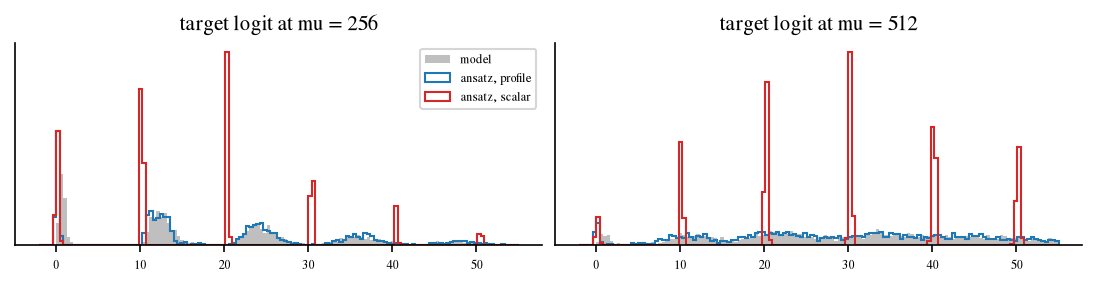

In [5]:
fig, axes = create_fig(ncols=2, size='double', h=0.25, sharex=False)
for ax, mu in zip(axes, mus):
    at_mu = real["mu"] == mu
    bins = np.linspace(-2, 55, 140)
    ax.hist(real["logits"][at_mu, -1].numpy(), bins=bins, density=True, color="gray", alpha=0.5, label="model")
    ax.hist(with_profile[at_mu, -1].numpy(), bins=bins, density=True, histtype="step", color="C0", label="ansatz, profile")
    ax.hist(with_scalar[at_mu, -1].numpy(), bins=bins, density=True, histtype="step", color="C3", label="ansatz, scalar")
    ax.set_title(f"target logit at mu = {mu}"); ax.set_yticks([])
axes[0].legend()
plt.show()

## 3. Sampling with the profile

`sample_variables` also returns the keys of every occurrence: `N_keys`, `F_keys` and `U_keys`. So the sampled variables use the profile too, with no closed form needed. Other changes from the scalar ansatz:
- the $K$ trigger logits, still equal within a vector, now spread from sequence to sequence, through $\widetilde{\mathcal N}$;
- the target and the trigger logits are correlated through the witness keys.

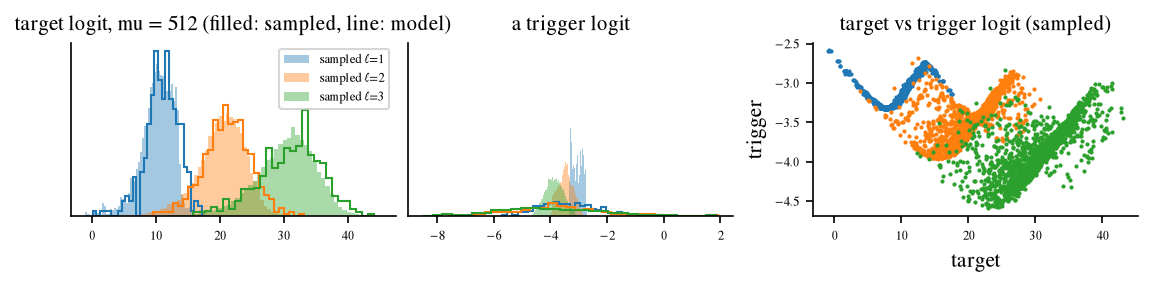

In [6]:
blocks = logit_blocks(K, V)
fig, axes = create_fig(ncols=3, size='double', h=0.25, sharex=False)
for ell, color in zip((1, 2, 3), ("C0", "C1", "C2")):
    sampled = sample_variables(512, ell, V, K, num_samples=20000, counts="multinomial", generator=torch.Generator().manual_seed(ell))
    logits = ansatz_logits(sampled, order_params, beta, L)
    measured = real.select(mu=512, ell=ell)["logits"]
    axes[0].hist(logits[:, -1].numpy(), bins=60, density=True, alpha=0.4, color=color, label=fr"sampled $\ell$={ell}")
    axes[0].hist(measured[:, -1].numpy(), bins=30, density=True, histtype="step", color=color)
    axes[1].hist(logits[:, 0].numpy(), bins=60, density=True, alpha=0.4, color=color)
    axes[1].hist(measured[:, 0].numpy(), bins=30, density=True, histtype="step", color=color)
    axes[2].scatter(logits[:2000, -1].numpy(), logits[:2000, 0].numpy(), s=1, color=color)
axes[0].set_title("target logit, mu = 512 (filled: sampled, line: model)"); axes[0].legend()
axes[1].set_title("a trigger logit"); axes[2].set_title("target vs trigger logit (sampled)")
axes[2].set_xlabel("target"); axes[2].set_ylabel("trigger")
for ax in axes[:2]:
    ax.set_yticks([])
plt.show()

## 4. The effective loss and its gradient over the keys

`EffectiveLoss` is differentiable in the profile. `value_and_grad` returns the gradient as a tensor of length $L-1$: the push the population loss exerts on every key.
- The `mean` method uses the mean of the profile over each query's keys.
- The `mc` method reads the profile at sampled keys.

**Sign:** $m_\nu<0$ in this run, so a *negative* drive makes a key stronger. At the last step the push is concentrated on the first ~20% of the keys: the early-key drive of the theory note.

effective loss: profile 4.2810 | scalar M_on 4.2816 | logged 4.2783


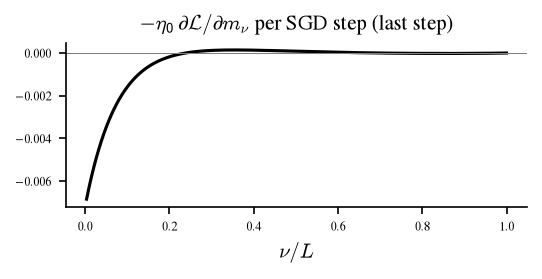

In [7]:
mean_loss = EffectiveLoss.from_config(config, method="mean", device=device)
value, gradient = mean_loss.value_and_grad(order_params)
print(f"effective loss: profile {value:.4f} | scalar M_on {mean_loss(scalar_params).item():.4f} | logged {run.metrics['loss'].iloc[-1]:.4f}")

fig, axes = create_fig(size='single', h=0.5)
axes.plot(x, -config.optim_args.alpha_lr * gradient["M_profile"].numpy(), color="k")
axes.axhline(0, lw=0.5, color="gray")
axes.set_xlabel(r"$\nu/L$"); axes.set_title(r"$-\eta_0\,\partial\mathcal{L}/\partial m_\nu$ per SGD step (last step)")
plt.show()

## 5. The flow of the profile

`integrate` can move the whole profile. Pass `"M_profile"` in both the initial values and the rates.
- **The profile's rate is exact.** Each entry of the profile *is* an entry of $\bm M$, so at $d=\infty$ its rate is just $\eta_0=$ `alpha_lr`, with no projection factor.
- **The other rates are placeholders.** $Q$ and $\Gamma$ still use $\alpha_{lr}/n_i$; replace them with your derived rates.
- **The trajectory** is in the column `"M_profile"`, one array per recorded step, and `"M_on"` reports its mean.

In [8]:
sizes = support_sizes(L, V, K)
rates = {name: config.optim_args.alpha_lr / sizes[name] for name in ("Q_on", "Q_T", "G_on", "G_T")}   # PLACEHOLDER
rates["M_profile"] = config.optim_args.alpha_lr                                                       # exact at d = inf
start = run.order_params("first", profile=True)
flow_loss = EffectiveLoss.from_config(config, method="mean", mus=range(8, L + 1, 8), device=device)
flow = integrate(flow_loss, start, rates, steps=run.metrics.index.max(), record_steps=run.metrics.index, method="RK45",
                 rtol=1e-4, atol=1e-7)
flow[["loss", "M_on", "Q_on", "G_on"]].iloc[::8].round(3)

,loss,M_on,Q_on,G_on
step,,,,
0.0,4.852,0.079,0.122,-0.103
490.0,4.852,0.070,0.076,-0.080
980.0,4.852,0.054,0.042,-0.056
1469.0,4.852,0.013,0.011,-0.019
1959.0,4.852,-0.151,-0.092,0.060
2449.0,4.342,-7.297,-36.251,17.675
2939.0,4.277,-10.506,-54.434,25.189


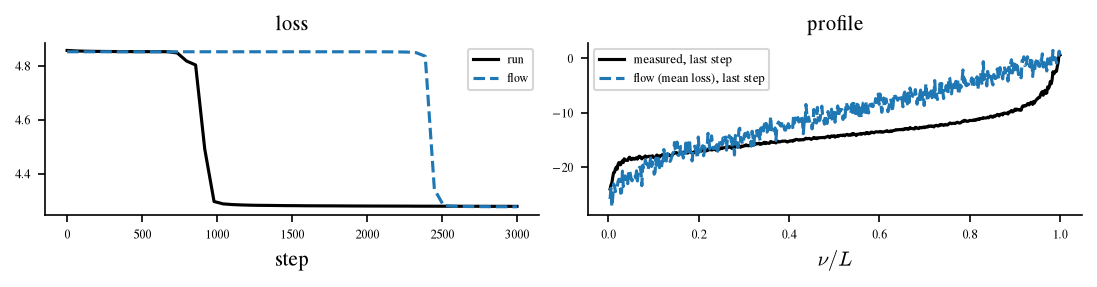

In [9]:
fig, axes = create_fig(ncols=2, size='double', h=0.25, sharex=False)
axes[0].plot(run.metrics.index, run.metrics["loss"], "k-", label="run")
axes[0].plot(flow.index, flow["loss"], "C0--", label="flow")
axes[0].set_xlabel("step"); axes[0].set_title("loss"); axes[0].legend()
final_step = flow.index[-1]
axes[1].plot(x, run.order_params("last", profile=True)["M_profile"].numpy(), "k-", label="measured, last step")
axes[1].plot(x, flow.loc[final_step, "M_profile"], "C0--", label="flow (mean loss), last step")
axes[1].set_xlabel(r"$\nu/L$"); axes[1].set_title("profile"); axes[1].legend()
plt.show()

**Reading it.**
- **The escape comes late** because the rates of $Q$ and $\Gamma$ are placeholders. The escape time is the test of the rates you derive.
- **The jagged profile** is the random initial profile: the flow adds smooth increments on top of it, while in training the noise of SGD and the finite-$d$ Gram matrices reshape it.
- **The profile decays too steeply.** The `mean` loss averages the profile over each query's keys. A key then never feels its own strength: in the theory note (Step 11) the drive on a key no longer shrinks as the key grows. Without that self-limitation the flow builds an exponential-like profile that decays too fast.

The `mc` method reads the profile at sampled witness keys, so it keeps the self-limitation. It is the method to use when the *shape* of the profile matters. Its flow is much slower: a gradient costs about `num_samples` times more, and with 511 moving entries the solver needs many of them. Run it outside the notebook.